# Thresholds - Étape 3

Ce notebook investigue l'optimisation des thresholds

In [1]:
%%html

<!-- styles d'affichage -->
<style>
    .section_div {
        width:70%;
        height:1.5px;
        border:none;
        color:black;
        background-color:black;
        margin: auto;
        margin-top: 0px;
        margin-bottom: 0px;
    }

    .answer {
        color:blue;
    }

    .question {
        color:red;
    }

    .note {
        color:green;
        font-weight: bold;
    }
</style>

In [2]:
# assure le reload de src si modifications sont faite
#
%load_ext autoreload
%autoreload 2

In [3]:
# import utilitaires
#
%matplotlib inline

import librosa as rosa
import math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

from pathlib import Path
from pprint import pprint
from tqdm.notebook import tqdm

In [4]:
# import package develope pour le projet
#
import ffury
from ffury.configs import (
    DatasetType,
    DEFAULT_CONFIG_FILE,
    load_config
)

def get_config():
    # creation config - on sait que DEFAULT_CONFIG_FILE est dans le repertoire parent
    config = Path(ffury.__file__).parents[2].joinpath(DEFAULT_CONFIG_FILE)
    return load_config(config)

config = get_config()

In [5]:
# donnees necessaire pour calculer les thresolds

from ffury.optional.development.dataset import IndexedDataset
from ffury.optional.keras_adapters import _load_model

# loading du model
model = _load_model(config)
model.summary()
model.layers[2].layer.summary()

print()

# loading des donnees
# pour garder nomenclature dans le code, data est entrainer avec TRAIN et valider avec VALIDATION
# TEST est vraiment a la fin pour mesurer performances globales
# TEST et VALIDATION n'entre jamais dans l'entrainement a proprement parle
data = IndexedDataset.create(config, DatasetType.VALIDATION)
x = data.spectrogram_groups
y_true = data.y
print("x shape:", x.shape)
print("y true shape:", y_true.shape )

print()

# probabilites par le modeles (modele a 2 output ; probabilites + features)
y_pred, _ = model.predict(x, verbose=0)
print("y pred. shape:", y_pred.shape)

2025-01-26 15:14:38.512829: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2025-01-26 15:14:38.512845: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2025-01-26 15:14:38.512848: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.00 GB
2025-01-26 15:14:38.512858: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-01-26 15:14:38.512865: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 5, 64, 20)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 5, 1280)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GroupFeatures (TimeDistributed) │ (None, 5, 2048)        │     1,713,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GroupProbabilities (Dense)      │ (None, 5, 5)           │        10,245 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GroupVoting                     │ (None, 5)              │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,164,561 (19.70 MB)

 Trainable params: 1,720,325 (6.56 MB)

...

 Trainable params: 1,710,080 (6.52 MB)

 Non-trainable params: 3,584 (14.00 KB)


x shape: (1372, 5, 64, 20)
y true shape: (1372, 5)



2025-01-26 15:14:38.947801: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


y pred. shape: (1372, 5)


In [6]:
# determiner meilleur thresholds par classes

from sklearn.metrics import f1_score

def to_labels(probabilities, thresholds):
    return (probabilities >= thresholds).astype(int)

all_scores = None
all_thresholds = []

for t in np.arange(0, 1, 0.001):
    y_labels = to_labels(y_pred, t)
    scores = f1_score(y_true, y_labels, average=None)

    if all_scores is None:
        all_scores = scores
    else:
        all_scores = np.vstack((all_scores, scores))

    all_thresholds.append(t)

best_scores_index = np.argmax(all_scores, axis=0)
best_scores = all_scores[best_scores_index, range(best_scores_index.shape[0])]
best_thresholds = np.array(all_thresholds)[best_scores_index]

print("Best f1 scores:", best_scores)
print("Best thresholds:", best_thresholds)

Best f1 scores: [0.63392857 0.64987406 0.47755102 0.75336323 0.70559611]
Best thresholds: [0.297 0.382 0.17  0.364 0.451]


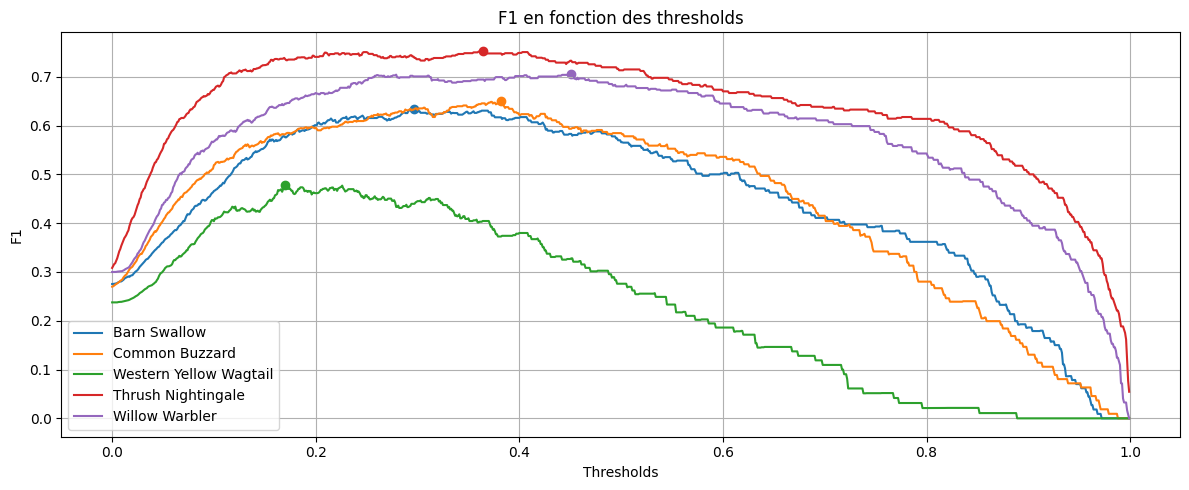

In [7]:
plt.figure(figsize=(12, 5))

for i, specie in enumerate(data.species_label):
    plt.plot(all_thresholds, all_scores[:, i], label=specie)
    plt.scatter(best_thresholds[i], best_scores[i])

plt.title("F1 en fonction des thresholds")
plt.ylabel("F1")
plt.xlabel("Thresholds")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()